In [62]:
import os
import numpy as np

from src.config_presets.tools.get_config import get_config


config = get_config('Xerostomia_model')

src\config_presets\Base_config.yaml
src\config_presets\Xerostomia_model.yaml


In [54]:
patient_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\PRI2MA\all_data_preprocessed_2025\dataset_full\9980149"
CT = np.load(os.path.join(patient_dir, "ct.npy"))[0]
RTDOSE = np.load(os.path.join(patient_dir, "rtdose.npy"))[0]
RTSTRUCT = np.load(os.path.join(patient_dir, "segmentation_map.npy"))[0]


# normalise the images
CT = np.clip(CT, -200, 400)
CT = (CT + 200) / 600

RTDOSE = np.clip(RTDOSE, 0, 8000)
RTDOSE = RTDOSE / 8000

RTSTRUCT = RTSTRUCT # (RTSTRUCT > 0).astype(int)


In [36]:
PET = np.load(os.path.join(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\5. Uncertainty\1. Data\Baoqiang\preprocessed_OS_dataset\9980149", "pet.npy"))
PET = PET[::2, :, :]
PET.shape

(96, 192, 192)

In [46]:
# rotate all images by 15 degrees in the axial plane
from scipy.ndimage import rotate

angle = 40
cval = 0

CT_rotated = rotate(CT, angle=angle, axes=(1,2), reshape=False, order=1, cval=0)
RTDOSE_rotated = rotate(RTDOSE, angle=angle, axes=(1,2), reshape=False, order=1, cval=cval)
RTSTRUCT_rotated = rotate(RTSTRUCT, angle=angle, axes=(1,2), reshape=False, order=0, cval=cval)

# make a flipped image
CT_flipped = np.flip(CT, axis=2)
RTDOSE_flipped = np.flip(RTDOSE, axis=2)
RTSTRUCT_flipped = np.flip(RTSTRUCT, axis=2)

In [56]:
# row_dicts = [
#     {"ct": CT * 600 -200,
#       "rtdose": RTDOSE * 8000,
#      "segmentation_map": RTSTRUCT ,
#      'Label': 'normal input',
#     },
#     {"ct": CT_rotated * 600 -200,
#      "rtdose": RTDOSE_rotated * 8000,
#      "segmentation_map": RTSTRUCT_rotated ,
#      'Label': 'Rotated input',
#     },
#     {"ct": CT_flipped * 600 -200,
#      "rtdose": RTDOSE_flipped * 8000,
#      "segmentation_map": RTSTRUCT_flipped ,
#      'Label': 'Flipped input',
#     },
#     {
#         'pet' : PET,
#         'Label': 'PET input',
#     }
# ]


row_dicts = [
    {"ct": CT * 600 -200,
      #"rtdose": RTDOSE * 8000,
     #"segmentation_map": RTSTRUCT ,
     'Label': 'CT',
    },
    {#"ct": CT_rotated * 600 -200,
     "rtdose": RTDOSE * 8000,
     #"segmentation_map": RTSTRUCT_rotated ,
     'Label': 'RTDose',
    },
    {#"ct": CT_flipped * 600 -200,
     #"rtdose": RTDOSE_flipped * 8000,
     "segmentation_map": RTSTRUCT ,
     'Label': 'RTSTRUCT',
    },
    {
        'pet': PET,
        'Label': 'PET',
    }
]



slice_indexes = [50, 60, 70, 80]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
src\config_presets\Base_config.yaml
src\config_presets\Xerostomia_model.yaml
layer_plotting_order ['ct', 'pet', 'rtdose', 'rtstruct', 'segmentation_map', 'gtv', 'attention']
colormap_layers ['attention', 'rtdose', 'pet', 'ct', 'gtv', 'rtstruct', 'segmentation_map']


C:\Users\macraedc\AppData\Local\Temp\ipykernel_22504\3836491459.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


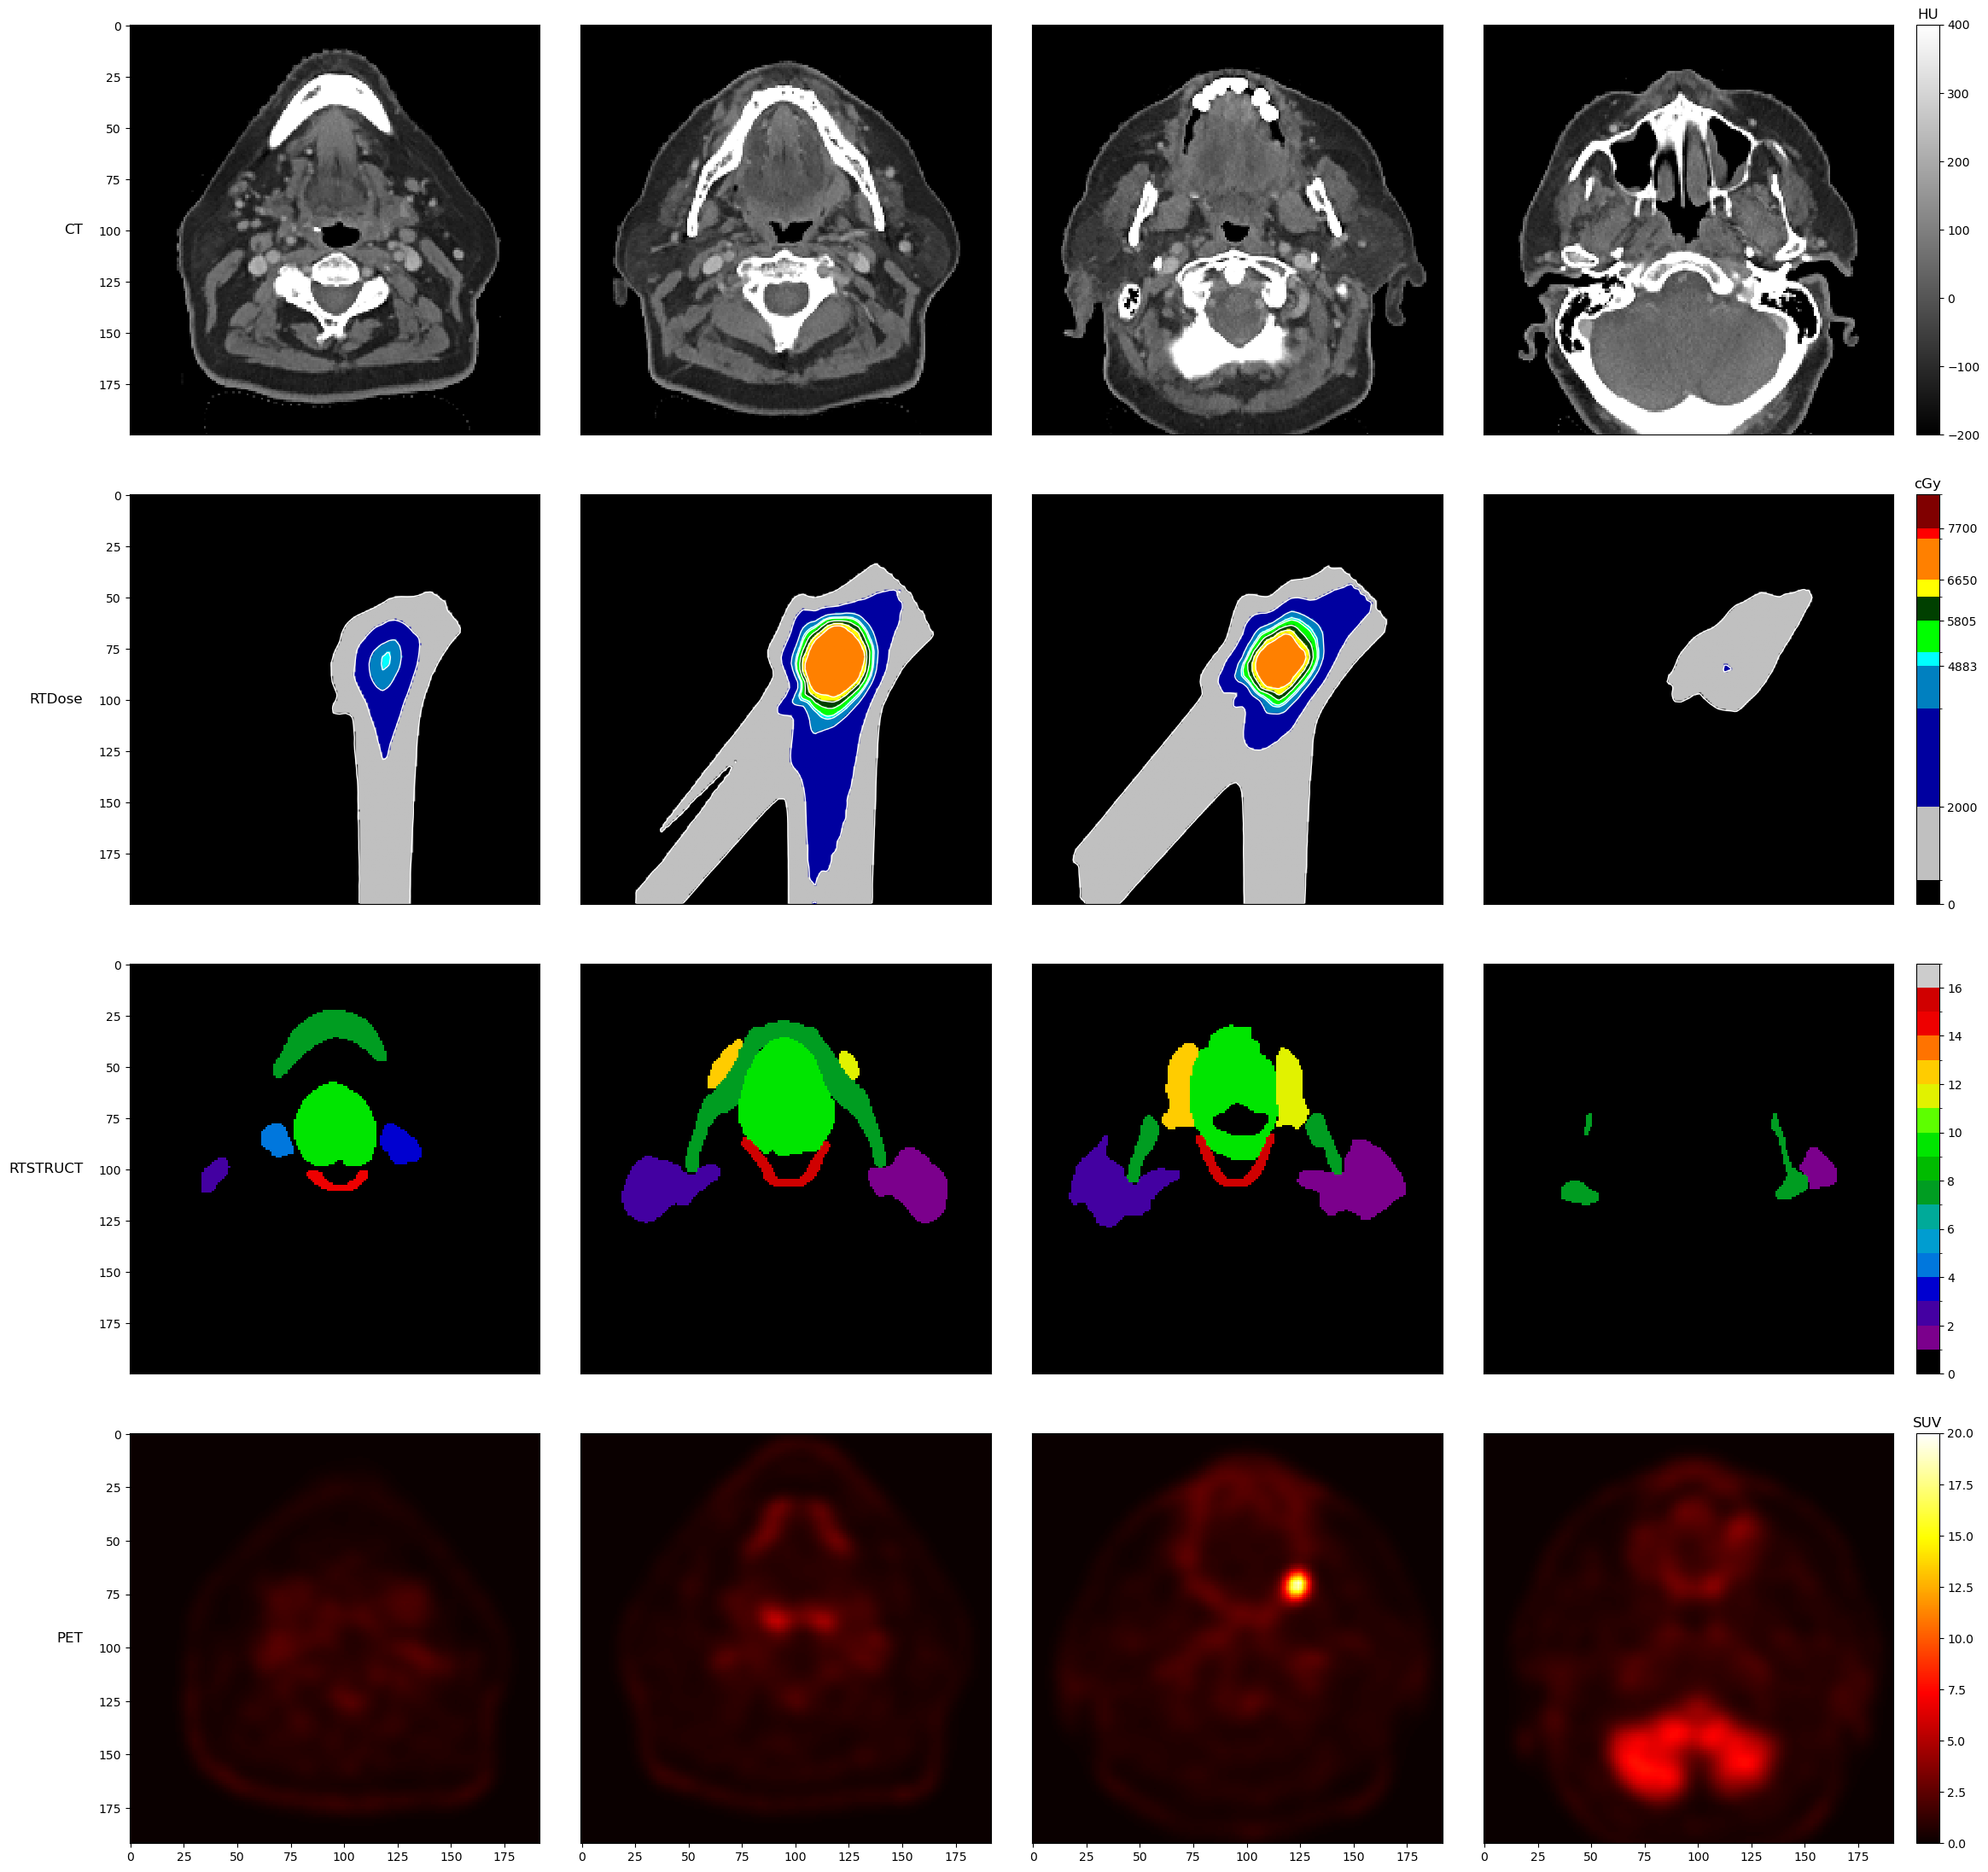

In [63]:
# PLOT
%load_ext autoreload
%autoreload 2
from src.visualization.plot_slices import plot_slices

config = get_config('Xerostomia_model')

fig, axes = plot_slices(
        config,
        row_dicts,
        slice_indexes,
        title=None,
        RT_region="HNC",
        plotting_axis="axial",
        verbose=False,
    )      

fig.show()

In [27]:
slice_with_max_value = np.unravel_index(np.argmax(PET), PET.shape)[0]
slice_with_max_value

136

In [26]:
from PIL import Image

In [ ]:
import PIL

print(PIL.__version__)

In [ ]:
import sys

print(sys.path)